# Guía 3 — Python aplicado a Data Analytics

**Tema:** `pandas`, indicadores, agrupaciones y visualización  
**Asignatura:** Programación para Analítica de Datos  
**Serie:** Python desde cero · Guía 3 de 4  
**Modalidad:** trabajo autónomo en Google Colab  
**Duración estimada:** 2 horas y 30 minutos a 3 horas  
**Prerrequisito:** haber completado las guías 1 y 2 o demostrar dominio equivalente de variables, listas, diccionarios, condiciones, ciclos y funciones.

## Propósito

Al terminar esta guía podrá:

1. convertir registros de Python en un `DataFrame`;
2. inspeccionar filas, columnas, tipos y estadísticas básicas;
3. seleccionar columnas y filtrar observaciones;
4. crear variables analíticas derivadas;
5. agrupar datos para construir KPI;
6. representar un indicador mediante una visualización;
7. encapsular el análisis en una función reproducible;
8. interpretar los resultados en un contexto profesional.

Esta guía no vuelve a enseñar los fundamentos de Python. El primer ejercicio funciona como verificación breve y como puente hacia `pandas`.

## Antes de comenzar

1. Abra el archivo en **Google Colab**.
2. Seleccione **Archivo → Guardar una copia en Drive**.
3. Ejecute las celdas en orden mediante el botón ▶.
4. Edite únicamente las celdas marcadas con `# TODO`.
5. Después de cada ejercicio, ejecute la celda **Autoevaluación**.
6. Si una respuesta no es correcta:
   - en el primer intento recibirá una pista;
   - en el segundo, una orientación más específica;
   - desde el tercero aparecerá una solución de emergencia.

### Convenciones

- ✅ ejercicio aprobado;
- 🟡 respuesta todavía incorrecta;
- 🧩 pista de apoyo;
- 🛟 solución de emergencia;
- 📊 progreso acumulado.

Equivocarse no reduce el puntaje. La meta es comprender el procedimiento y lograr una solución verificable.

## Caso profesional

El **Restaurante La Analítica** consolidó 16 transacciones de dos semanas y dos sedes. La gerencia necesita responder preguntas concretas:

- ¿cuánto vendió y qué margen bruto obtuvo?;
- ¿qué productos y sedes lideran los ingresos?;
- ¿qué clientes regresaron en la segunda semana?;
- ¿cómo comunicar los resultados de forma reproducible?

La ruta de trabajo será:

`lista de diccionarios → DataFrame → inspección → filtrado → transformación → agrupación → visualización → resumen ejecutivo`

Cada etapa produce una evidencia que será utilizada por la siguiente.

# 0. Prepare el entorno

Ejecute la siguiente celda una sola vez. Importa las bibliotecas, activa la autoevaluación y habilita la exportación del reporte final.

In [25]:
import html
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display, HTML

PUNTAJES = {
    "E1": 10,
    "E2": 15,
    "E3": 15,
    "E4": 15,
    "E5": 20,
    "E6": 10,
    "E7": 15,
}

if "RESULTADOS" not in globals():
    RESULTADOS = {}
if "INTENTOS" not in globals():
    INTENTOS = {}

nombre_estudiante = globals().get("nombre_estudiante", "")

def _tarjeta(mensaje, color_fondo, color_borde):
    display(HTML(
        f"""
        <div style="padding:14px 18px;margin:10px 0;border-radius:10px;
                    background:{color_fondo};border-left:6px solid {color_borde};">
            {mensaje}
        </div>
        """
    ))

def evaluar(ejercicio, prueba, pistas, solucion):
    """Comprueba un ejercicio y entrega apoyo progresivo sin bloquear el cuaderno."""
    try:
        aprobado = bool(prueba())
        detalle_error = ""
    except Exception as exc:
        aprobado = False
        detalle_error = f"{type(exc).__name__}: {exc}"

    if aprobado:
        RESULTADOS[ejercicio] = PUNTAJES[ejercicio]
        _tarjeta(
            f"<b>✅ {ejercicio} aprobado.</b> Obtuvo {PUNTAJES[ejercicio]} puntos.",
            "#eaf7ef",
            "#2e8b57",
        )
        return True

    INTENTOS[ejercicio] = INTENTOS.get(ejercicio, 0) + 1
    intento = INTENTOS[ejercicio]
    RESULTADOS.setdefault(ejercicio, 0)

    mensaje = f"<b>🟡 {ejercicio}: todavía no es correcto.</b><br>"
    if detalle_error:
        mensaje += (
            "<span style='color:#8a3b12;'>Detalle técnico: "
            f"{html.escape(detalle_error)}</span><br>"
        )

    if intento == 1:
        mensaje += f"<b>🧩 Pista 1:</b> {html.escape(pistas[0])}"
    elif intento == 2:
        mensaje += f"<b>🧩 Pista 2:</b> {html.escape(pistas[1])}"
    else:
        mensaje += (
            "<b>🛟 Solución de emergencia:</b><br>"
            "<pre style='background:#fff;padding:10px;border-radius:6px;'>"
            f"{html.escape(solucion)}</pre>"
            "Copie la solución en la celda del ejercicio, ejecútela y vuelva a comprobar."
        )

    _tarjeta(mensaje, "#fff7e6", "#f0a000")
    return False

def mostrar_progreso():
    total = sum(RESULTADOS.get(ejercicio, 0) for ejercicio in PUNTAJES)
    aprobados = [
        ejercicio
        for ejercicio in PUNTAJES
        if RESULTADOS.get(ejercicio, 0) > 0
    ]
    pendientes = [
        ejercicio
        for ejercicio in PUNTAJES
        if RESULTADOS.get(ejercicio, 0) == 0
    ]

    color = (
        "#2e8b57"
        if total >= 80
        else "#f0a000"
        if total >= 60
        else "#b23a48"
    )

    _tarjeta(
        f"<b>📊 Progreso: {total}/100 puntos</b><br>"
        f"Aprobados: {', '.join(aprobados) if aprobados else 'ninguno'}<br>"
        f"Pendientes: {', '.join(pendientes) if pendientes else 'ninguno'}",
        "#f4f7fb",
        color,
    )

def exportar_autoevaluacion(nombre="estudiante"):
    nombre_limpio = str(nombre).strip()
    if not nombre_limpio or nombre_limpio == "Escriba aquí su nombre":
        nombre_limpio = "estudiante"

    registros = []
    for ejercicio, puntaje_maximo in PUNTAJES.items():
        registros.append(
            {
                "estudiante": nombre_limpio,
                "ejercicio": ejercicio,
                "puntaje_obtenido": RESULTADOS.get(ejercicio, 0),
                "puntaje_maximo": puntaje_maximo,
                "intentos": INTENTOS.get(ejercicio, 0),
            }
        )

    resultado = pd.DataFrame(registros)
    nombre_seguro = (
        re.sub(r"[^A-Za-z0-9_-]+", "_", nombre_limpio).strip("_")
        or "estudiante"
    )
    archivo = Path(f"autoevaluacion_guia3_{nombre_seguro}.csv")
    resultado.to_csv(archivo, index=False, encoding="utf-8-sig")

    print(f"Archivo creado: {archivo.name}")
    display(resultado)

    try:
        from google.colab import files
        files.download(str(archivo))
    except Exception:
        print("Fuera de Colab, el archivo quedó guardado en el directorio actual.")

print("✅ Entorno preparado. Puede comenzar.")
mostrar_progreso()

✅ Entorno preparado. Puede comenzar.


## Identificación

Reemplace el texto por su nombre. Este dato se utiliza únicamente para nombrar el reporte de autoevaluación.

In [26]:
# TODO: reemplace el texto por su nombre
nombre_estudiante = "Stiven"

print("Estudiante:", nombre_estudiante)

Estudiante: Stiven


# 1. Puente diagnóstico: de registros a un resumen

Antes de utilizar `pandas`, verifique que reconoce la estructura que ya trabajó en la Guía 2:

- una **lista** reúne varios registros;
- cada **diccionario** representa una transacción;
- una **función** permite aplicar la misma regla a cualquier colección compatible.

## Ejercicio E1 — Resumir registros con Python (10 puntos)

Complete `resumir_registros(registros)` para retornar un diccionario con:

- `numero_transacciones`;
- `unidades`;
- `ingreso`.

No utilice `pandas` en este ejercicio.

In [30]:
# TODO E1
muestra_registros = [
    {"producto": "Bowl Andino", "cantidad": 2, "precio_unitario": 24000},
    {"producto": "Pasta Urbana", "cantidad": 1, "precio_unitario": 28000},
    {"producto": "Limonada Natural", "cantidad": 3, "precio_unitario": 8000},
]

def resumir_registros(registros):
    unidades = 0
    ingreso = 0

    for registro in registros:
        unidades += registro["cantidad"]
        ingreso += (
            registro["cantidad"]
            * registro["precio_unitario"]
        )

    return {
        "numero_transacciones": len(registros),
        "unidades": unidades,
        "ingreso": ingreso,
    }

resumen_muestra = resumir_registros(muestra_registros)
print(resumen_muestra)

{'numero_transacciones': 3, 'unidades': 6, 'ingreso': 100000}


In [31]:
# Autoevaluación E1
evaluar(
    "E1",
    lambda: resumir_registros(muestra_registros) == {
        "numero_transacciones": 3,
        "unidades": 6,
        "ingreso": 100000,
    },
    pistas=[
        "Inicialice en cero los acumuladores de unidades e ingreso y recorra cada diccionario.",
        "El ingreso de cada registro es cantidad por precio_unitario; el número de transacciones se obtiene con len(registros).",
    ],
    solucion='''
def resumir_registros(registros):
    unidades = 0
    ingreso = 0

    for registro in registros:
        unidades += registro["cantidad"]
        ingreso += (
            registro["cantidad"]
            * registro["precio_unitario"]
        )

    return {
        "numero_transacciones": len(registros),
        "unidades": unidades,
        "ingreso": ingreso,
    }
'''
)

True

# 2. De una lista de diccionarios a un `DataFrame`

Un `DataFrame` organiza los registros en una tabla:

- cada fila representa una transacción;
- cada columna representa una variable;
- cada columna conserva un tipo de dato.

La ventaja no consiste solamente en “ver una tabla”. `pandas` permite seleccionar, transformar, agrupar y resumir los datos con operaciones reproducibles.

In [32]:
# Datos autocontenidos del caso Restaurante La Analítica
datos_ventas = [
    {"semana": 1, "fecha": "2026-08-03", "cliente_id": 101, "producto": "Bowl Andino", "categoria": "Almuerzo", "cantidad": 2, "precio_unitario": 24000, "costo_unitario": 14000, "sede": "Centro"},
    {"semana": 1, "fecha": "2026-08-03", "cliente_id": 102, "producto": "Pasta Urbana", "categoria": "Almuerzo", "cantidad": 1, "precio_unitario": 28000, "costo_unitario": 17000, "sede": "Norte"},
    {"semana": 1, "fecha": "2026-08-04", "cliente_id": 103, "producto": "Bowl Andino", "categoria": "Almuerzo", "cantidad": 1, "precio_unitario": 24000, "costo_unitario": 14000, "sede": "Centro"},
    {"semana": 1, "fecha": "2026-08-04", "cliente_id": 104, "producto": "Hamburguesa Central", "categoria": "Cena", "cantidad": 2, "precio_unitario": 30000, "costo_unitario": 19000, "sede": "Norte"},
    {"semana": 1, "fecha": "2026-08-05", "cliente_id": 105, "producto": "Ensalada de la Casa", "categoria": "Almuerzo", "cantidad": 1, "precio_unitario": 22000, "costo_unitario": 12000, "sede": "Centro"},
    {"semana": 1, "fecha": "2026-08-05", "cliente_id": 101, "producto": "Limonada Natural", "categoria": "Bebida", "cantidad": 2, "precio_unitario": 8000, "costo_unitario": 2500, "sede": "Centro"},
    {"semana": 1, "fecha": "2026-08-06", "cliente_id": 106, "producto": "Pasta Urbana", "categoria": "Almuerzo", "cantidad": 2, "precio_unitario": 28000, "costo_unitario": 17000, "sede": "Norte"},
    {"semana": 1, "fecha": "2026-08-07", "cliente_id": 107, "producto": "Bowl Andino", "categoria": "Almuerzo", "cantidad": 3, "precio_unitario": 24000, "costo_unitario": 14000, "sede": "Centro"},
    {"semana": 2, "fecha": "2026-08-10", "cliente_id": 101, "producto": "Pasta Urbana", "categoria": "Almuerzo", "cantidad": 1, "precio_unitario": 28000, "costo_unitario": 17000, "sede": "Centro"},
    {"semana": 2, "fecha": "2026-08-10", "cliente_id": 108, "producto": "Hamburguesa Central", "categoria": "Cena", "cantidad": 1, "precio_unitario": 30000, "costo_unitario": 19000, "sede": "Norte"},
    {"semana": 2, "fecha": "2026-08-11", "cliente_id": 103, "producto": "Bowl Andino", "categoria": "Almuerzo", "cantidad": 2, "precio_unitario": 24000, "costo_unitario": 14000, "sede": "Centro"},
    {"semana": 2, "fecha": "2026-08-11", "cliente_id": 109, "producto": "Ensalada de la Casa", "categoria": "Almuerzo", "cantidad": 2, "precio_unitario": 22000, "costo_unitario": 12000, "sede": "Centro"},
    {"semana": 2, "fecha": "2026-08-12", "cliente_id": 104, "producto": "Hamburguesa Central", "categoria": "Cena", "cantidad": 1, "precio_unitario": 30000, "costo_unitario": 19000, "sede": "Norte"},
    {"semana": 2, "fecha": "2026-08-12", "cliente_id": 110, "producto": "Limonada Natural", "categoria": "Bebida", "cantidad": 3, "precio_unitario": 8000, "costo_unitario": 2500, "sede": "Centro"},
    {"semana": 2, "fecha": "2026-08-13", "cliente_id": 106, "producto": "Pasta Urbana", "categoria": "Almuerzo", "cantidad": 1, "precio_unitario": 28000, "costo_unitario": 17000, "sede": "Norte"},
    {"semana": 2, "fecha": "2026-08-14", "cliente_id": 111, "producto": "Bowl Andino", "categoria": "Almuerzo", "cantidad": 2, "precio_unitario": 24000, "costo_unitario": 14000, "sede": "Centro"},
]

print("Registros disponibles:", len(datos_ventas))

Registros disponibles: 16


## Ejemplo guiado

Observe cómo los dos primeros diccionarios se convierten en una tabla. Ejecute la celda sin modificarla.

In [33]:
ejemplo_df = pd.DataFrame(datos_ventas[:2])
display(ejemplo_df)

,semana,fecha,cliente_id,producto,categoria,cantidad,precio_unitario,costo_unitario,sede
0,1,2026-08-03,101,Bowl Andino,Almuerzo,2,24000,14000,Centro
1,1,2026-08-03,102,Pasta Urbana,Almuerzo,1,28000,17000,Norte


## Ejercicio E2 — Crear e inspeccionar el `DataFrame` (15 puntos)

1. Convierta `datos_ventas` en `df_ventas`.
2. Convierta `fecha` mediante `pd.to_datetime()`.
3. Guarde el número de filas en `numero_filas`.
4. Guarde el número de columnas en `numero_columnas`.
5. Guarde los nombres de las columnas en `columnas_disponibles`.
6. Muestre las primeras cinco filas.

In [35]:
# TODO E2
df_ventas = None

# Convierta la columna fecha

numero_filas = None
numero_columnas = None
columnas_disponibles = None

# Muestre las primeras cinco filas
df_ventas = pd.DataFrame(datos_ventas)
df_ventas["fecha"] = pd.to_datetime(
    df_ventas["fecha"]
)

numero_filas, numero_columnas = df_ventas.shape
columnas_disponibles = list(df_ventas.columns)

display(df_ventas.head())

,semana,fecha,cliente_id,producto,categoria,cantidad,precio_unitario,costo_unitario,sede
0,1,2026-08-03,101,Bowl Andino,Almuerzo,2,24000,14000,Centro
1,1,2026-08-03,102,Pasta Urbana,Almuerzo,1,28000,17000,Norte
2,1,2026-08-04,103,Bowl Andino,Almuerzo,1,24000,14000,Centro
3,1,2026-08-04,104,Hamburguesa Central,Cena,2,30000,19000,Norte
4,1,2026-08-05,105,Ensalada de la Casa,Almuerzo,1,22000,12000,Centro


In [36]:
# Autoevaluación E2
evaluar(
    "E2",
    lambda: (
        isinstance(df_ventas, pd.DataFrame)
        and df_ventas.shape == (16, 9)
        and pd.api.types.is_datetime64_any_dtype(df_ventas["fecha"])
        and numero_filas == 16
        and numero_columnas == 9
        and columnas_disponibles == [
            "semana",
            "fecha",
            "cliente_id",
            "producto",
            "categoria",
            "cantidad",
            "precio_unitario",
            "costo_unitario",
            "sede",
        ]
    ),
    pistas=[
        "Use pd.DataFrame(datos_ventas) y consulte df_ventas.shape.",
        "La forma general es df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha']); convierta las columnas a una lista con list(df_ventas.columns).",
    ],
    solucion='''
df_ventas = pd.DataFrame(datos_ventas)
df_ventas["fecha"] = pd.to_datetime(
    df_ventas["fecha"]
)

numero_filas, numero_columnas = df_ventas.shape
columnas_disponibles = list(df_ventas.columns)

display(df_ventas.head())
'''
)

True

## Lectura guiada de la estructura

Ejecute la siguiente celda después de aprobar E2.

Al interpretar la salida, tenga presente que `cliente_id` aparece como número, pero funciona como **identificador**, no como una medida sobre la que tenga sentido calcular un promedio.

In [9]:
if isinstance(df_ventas, pd.DataFrame):
    display(df_ventas.head())
    print("Dimensiones:", df_ventas.shape)
    print("\nTipos de datos:")
    display(df_ventas.dtypes.to_frame("tipo"))
    print("\nResumen de variables numéricas:")
    display(df_ventas.describe())
else:
    print(
        "Complete y apruebe E2 para habilitar "
        "la lectura guiada del DataFrame."
    )

Complete y apruebe E2 para habilitar la lectura guiada del DataFrame.


# 3. Selección y filtrado

Dos operaciones básicas de análisis son:

- **seleccionar columnas:** conservar únicamente las variables necesarias;
- **filtrar filas:** conservar únicamente las observaciones que cumplen una condición.

Para combinar condiciones en `pandas`, cada comparación se escribe entre paréntesis y se utilizan `&` para “y” y `|` para “o”.

## Ejercicio E3 — Analizar almuerzos de la sede Centro (15 puntos)

Cree `ventas_centro_almuerzo` con:

- únicamente registros cuya sede sea `"Centro"` **y** categoría sea `"Almuerzo"`;
- solamente las columnas `fecha`, `cliente_id`, `producto`, `cantidad`, `sede` y `categoria`.

Después calcule `unidades_centro_almuerzo`.

In [38]:
# TODO E3
columnas_analisis = [
    "fecha",
    "cliente_id",
    "producto",
    "cantidad",
    "sede",
    "categoria",
]

ventas_centro_almuerzo = None
unidades_centro_almuerzo = None
mascara = (
    (df_ventas["sede"] == "Centro")
    & (df_ventas["categoria"] == "Almuerzo")
)

ventas_centro_almuerzo = df_ventas.loc[
    mascara,
    columnas_analisis,
].copy()

unidades_centro_almuerzo = (
    ventas_centro_almuerzo["cantidad"].sum()
)

display(ventas_centro_almuerzo)

display(ventas_centro_almuerzo)

,fecha,cliente_id,producto,cantidad,sede,categoria
0,2026-08-03,101,Bowl Andino,2,Centro,Almuerzo
2,2026-08-04,103,Bowl Andino,1,Centro,Almuerzo
4,2026-08-05,105,Ensalada de la Casa,1,Centro,Almuerzo
7,2026-08-07,107,Bowl Andino,3,Centro,Almuerzo
8,2026-08-10,101,Pasta Urbana,1,Centro,Almuerzo
10,2026-08-11,103,Bowl Andino,2,Centro,Almuerzo
11,2026-08-11,109,Ensalada de la Casa,2,Centro,Almuerzo
15,2026-08-14,111,Bowl Andino,2,Centro,Almuerzo


,fecha,cliente_id,producto,cantidad,sede,categoria
0,2026-08-03,101,Bowl Andino,2,Centro,Almuerzo
2,2026-08-04,103,Bowl Andino,1,Centro,Almuerzo
4,2026-08-05,105,Ensalada de la Casa,1,Centro,Almuerzo
7,2026-08-07,107,Bowl Andino,3,Centro,Almuerzo
8,2026-08-10,101,Pasta Urbana,1,Centro,Almuerzo
10,2026-08-11,103,Bowl Andino,2,Centro,Almuerzo
11,2026-08-11,109,Ensalada de la Casa,2,Centro,Almuerzo
15,2026-08-14,111,Bowl Andino,2,Centro,Almuerzo


In [39]:
# Autoevaluación E3
evaluar(
    "E3",
    lambda: (
        isinstance(ventas_centro_almuerzo, pd.DataFrame)
        and ventas_centro_almuerzo.shape == (8, 6)
        and list(ventas_centro_almuerzo.columns) == columnas_analisis
        and ventas_centro_almuerzo["sede"].eq("Centro").all()
        and ventas_centro_almuerzo["categoria"].eq("Almuerzo").all()
        and unidades_centro_almuerzo == 14
    ),
    pistas=[
        "Construya una máscara con (df_ventas['sede'] == 'Centro') & (df_ventas['categoria'] == 'Almuerzo').",
        "Use df_ventas.loc[mascara, columnas_analisis].copy() y después sume la columna cantidad.",
    ],
    solucion='''
mascara = (
    (df_ventas["sede"] == "Centro")
    & (df_ventas["categoria"] == "Almuerzo")
)

ventas_centro_almuerzo = df_ventas.loc[
    mascara,
    columnas_analisis,
].copy()

unidades_centro_almuerzo = (
    ventas_centro_almuerzo["cantidad"].sum()
)

display(ventas_centro_almuerzo)
'''
)

True

# 4. Variables derivadas y KPI globales

Una variable derivada se calcula a partir de columnas existentes. En este caso:

- `ingreso = cantidad × precio_unitario`;
- `costo_total = cantidad × costo_unitario`;
- `margen_bruto = ingreso − costo_total`;
- `porcentaje_margen = margen_bruto / ingreso × 100`.

El porcentaje global debe calcularse después de sumar ingresos y márgenes. Promediar porcentajes por transacción puede producir una lectura diferente.

## Ejercicio E4 — Construir indicadores por transacción y globales (15 puntos)

Agregue las cuatro columnas y calcule:

- `ingreso_total`;
- `margen_total`;
- `porcentaje_margen_global`, redondeado a dos decimales.

In [41]:
# TODO E4
# Cree ingreso, costo_total, margen_bruto y porcentaje_margen

ingreso_total = None
margen_total = None
porcentaje_margen_global = None
df_ventas["ingreso"] = (
    df_ventas["cantidad"]
    * df_ventas["precio_unitario"]
)
df_ventas["costo_total"] = (
    df_ventas["cantidad"]
    * df_ventas["costo_unitario"]
)
df_ventas["margen_bruto"] = (
    df_ventas["ingreso"]
    - df_ventas["costo_total"]
)
df_ventas["porcentaje_margen"] = (
    df_ventas["margen_bruto"]
    / df_ventas["ingreso"]
    * 100
)

ingreso_total = df_ventas["ingreso"].sum()
margen_total = df_ventas["margen_bruto"].sum()
porcentaje_margen_global = round(
    (margen_total / ingreso_total) * 100,
    2,
)

print("Ingreso total:", ingreso_total)
print("Margen total:", margen_total)
print("Porcentaje de margen global:", porcentaje_margen_global)

Ingreso total: 606000
Margen total: 256500
Porcentaje de margen global: 42.33


In [42]:
# Autoevaluación E4
evaluar(
    "E4",
    lambda: (
        {
            "ingreso",
            "costo_total",
            "margen_bruto",
            "porcentaje_margen",
        }.issubset(df_ventas.columns)
        and df_ventas["ingreso"].sum() == 606000
        and df_ventas["costo_total"].sum() == 349500
        and df_ventas["margen_bruto"].sum() == 256500
        and np.allclose(
            df_ventas["porcentaje_margen"],
            (
                df_ventas["margen_bruto"]
                / df_ventas["ingreso"]
                * 100
            ),
        )
        and ingreso_total == 606000
        and margen_total == 256500
        and porcentaje_margen_global == 42.33
    ),
    pistas=[
        "Las operaciones entre columnas se escriben igual que las operaciones entre variables.",
        "Calcule primero los totales y después round((margen_total / ingreso_total) * 100, 2).",
    ],
    solucion='''
df_ventas["ingreso"] = (
    df_ventas["cantidad"]
    * df_ventas["precio_unitario"]
)
df_ventas["costo_total"] = (
    df_ventas["cantidad"]
    * df_ventas["costo_unitario"]
)
df_ventas["margen_bruto"] = (
    df_ventas["ingreso"]
    - df_ventas["costo_total"]
)
df_ventas["porcentaje_margen"] = (
    df_ventas["margen_bruto"]
    / df_ventas["ingreso"]
    * 100
)

ingreso_total = df_ventas["ingreso"].sum()
margen_total = df_ventas["margen_bruto"].sum()
porcentaje_margen_global = round(
    (margen_total / ingreso_total) * 100,
    2,
)
'''
)

True

## Pausa de control

Ejecute la siguiente celda. Un resultado de **55/100** significa que completó el puente diagnóstico, la creación del `DataFrame`, el filtrado y las variables derivadas.

In [43]:
mostrar_progreso()

# 5. Agrupaciones para construir KPI

`groupby()` reúne las filas que comparten una categoría. `agg()` define qué cálculo realizar sobre cada grupo.

Es importante distinguir:

- **suma:** ingresos, costos, márgenes y unidades;
- **conteo:** número de transacciones;
- **razón:** porcentaje de margen, calculado después de obtener los totales agrupados.

## Ejercicio E5 — KPI por producto y sede (20 puntos)

Construya:

**`kpi_producto`**
- `producto`;
- `unidades`;
- `ingreso`;
- `margen`;
- `porcentaje_margen`.

**`kpi_sede`**
- `sede`;
- `transacciones`;
- `unidades`;
- `ingreso`;
- `margen`;
- `porcentaje_margen`.

Ordene ambas tablas de mayor a menor ingreso y obtenga `producto_lider` y `sede_lider`.

In [45]:
# TODO E5
kpi_producto = None
kpi_sede = None

producto_lider = None
sede_lider = None
kpi_producto = (
    df_ventas.groupby(
        "producto",
        as_index=False,
    )
    .agg(
        unidades=("cantidad", "sum"),
        ingreso=("ingreso", "sum"),
        margen=("margen_bruto", "sum"),
    )
    .sort_values("ingreso", ascending=False)
    .reset_index(drop=True)
)
kpi_producto["porcentaje_margen"] = (
    kpi_producto["margen"]
    / kpi_producto["ingreso"]
    * 100
).round(2)

kpi_sede = (
    df_ventas.groupby(
        "sede",
        as_index=False,
    )
    .agg(
        transacciones=("cliente_id", "size"),
        unidades=("cantidad", "sum"),
        ingreso=("ingreso", "sum"),
        margen=("margen_bruto", "sum"),
    )
    .sort_values("ingreso", ascending=False)
    .reset_index(drop=True)
)
kpi_sede["porcentaje_margen"] = (
    kpi_sede["margen"]
    / kpi_sede["ingreso"]
    * 100
).round(2)

producto_lider = kpi_producto.loc[0, "producto"]
sede_lider = kpi_sede.loc[0, "sede"]

display(kpi_producto)
display(kpi_sede)


,producto,unidades,ingreso,margen,porcentaje_margen
0,Bowl Andino,10,240000,100000,41.67
1,Pasta Urbana,5,140000,55000,39.29
2,Hamburguesa Central,4,120000,44000,36.67
3,Ensalada de la Casa,3,66000,30000,45.45
4,Limonada Natural,5,40000,27500,68.75


,sede,transacciones,unidades,ingreso,margen,porcentaje_margen
0,Centro,10,19,374000,168500,45.05
1,Norte,6,8,232000,88000,37.93


In [46]:
# Autoevaluación E5
def _comprobar_kpi():
    return (
        isinstance(kpi_producto, pd.DataFrame)
        and isinstance(kpi_sede, pd.DataFrame)
        and list(kpi_producto.columns) == [
            "producto",
            "unidades",
            "ingreso",
            "margen",
            "porcentaje_margen",
        ]
        and list(kpi_sede.columns) == [
            "sede",
            "transacciones",
            "unidades",
            "ingreso",
            "margen",
            "porcentaje_margen",
        ]
        and kpi_producto.shape == (5, 5)
        and kpi_sede.shape == (2, 6)
        and kpi_producto.iloc[0]["producto"] == "Bowl Andino"
        and kpi_producto.iloc[0]["unidades"] == 10
        and kpi_producto.iloc[0]["ingreso"] == 240000
        and kpi_sede.iloc[0]["sede"] == "Centro"
        and kpi_sede.iloc[0]["ingreso"] == 374000
        and producto_lider == "Bowl Andino"
        and sede_lider == "Centro"
        and np.allclose(
            kpi_producto["porcentaje_margen"],
            (
                kpi_producto["margen"]
                / kpi_producto["ingreso"]
                * 100
            ).round(2),
        )
        and np.allclose(
            kpi_sede["porcentaje_margen"],
            (
                kpi_sede["margen"]
                / kpi_sede["ingreso"]
                * 100
            ).round(2),
        )
    )

evaluar(
    "E5",
    _comprobar_kpi,
    pistas=[
        "Use groupby(..., as_index=False).agg(nombre_nuevo=('columna', 'operacion')).",
        "Después de agregar, calcule porcentaje_margen, ordene con sort_values('ingreso', ascending=False) y restablezca el índice.",
    ],
    solucion='''
kpi_producto = (
    df_ventas.groupby(
        "producto",
        as_index=False,
    )
    .agg(
        unidades=("cantidad", "sum"),
        ingreso=("ingreso", "sum"),
        margen=("margen_bruto", "sum"),
    )
    .sort_values("ingreso", ascending=False)
    .reset_index(drop=True)
)
kpi_producto["porcentaje_margen"] = (
    kpi_producto["margen"]
    / kpi_producto["ingreso"]
    * 100
).round(2)

kpi_sede = (
    df_ventas.groupby(
        "sede",
        as_index=False,
    )
    .agg(
        transacciones=("cliente_id", "size"),
        unidades=("cantidad", "sum"),
        ingreso=("ingreso", "sum"),
        margen=("margen_bruto", "sum"),
    )
    .sort_values("ingreso", ascending=False)
    .reset_index(drop=True)
)
kpi_sede["porcentaje_margen"] = (
    kpi_sede["margen"]
    / kpi_sede["ingreso"]
    * 100
).round(2)

producto_lider = kpi_producto.loc[0, "producto"]
sede_lider = kpi_sede.loc[0, "sede"]

display(kpi_producto)
display(kpi_sede)
'''
)

True

# 6. Visualización orientada a una pregunta

El gráfico no reemplaza la tabla. Su función es facilitar una comparación específica.

**Pregunta:** ¿cómo se distribuye el ingreso entre los productos?

## Ejercicio E6 — Gráfico e interpretación (10 puntos)

1. Construya un gráfico horizontal de barras con el ingreso por producto.
2. Ordene los productos de menor a mayor ingreso.
3. Defina título y nombres de los ejes.
4. Escriba en `hallazgo_grafico` una frase de al menos 40 caracteres que mencione el producto líder.

Bowl Andino lidera el ingreso y supera ampliamente a los demás productos del menú.


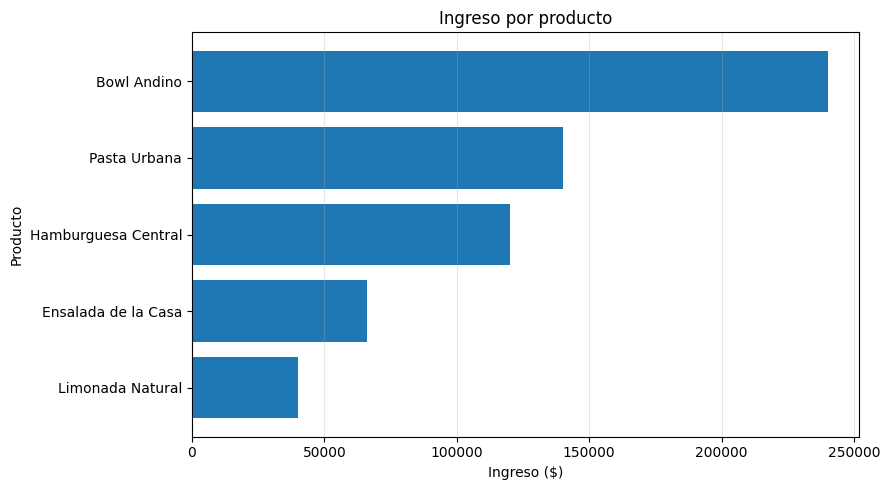

In [48]:
# TODO E6
datos_grafico = None
fig = None
ax = None

# Construya el gráfico

hallazgo_grafico = ""
datos_grafico = kpi_producto.sort_values(
    "ingreso",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    datos_grafico["producto"],
    datos_grafico["ingreso"],
)
ax.set_title("Ingreso por producto")
ax.set_xlabel("Ingreso ($)")
ax.set_ylabel("Producto")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

hallazgo_grafico = (
    "Bowl Andino lidera el ingreso y supera "
    "ampliamente a los demás productos del menú."
)

print(hallazgo_grafico)

In [49]:
# Autoevaluación E6
def _comprobar_grafico():
    return (
        isinstance(datos_grafico, pd.DataFrame)
        and isinstance(fig, Figure)
        and ax is not None
        and len(ax.patches) == 5
        and bool(ax.get_title().strip())
        and bool(ax.get_xlabel().strip())
        and bool(ax.get_ylabel().strip())
        and isinstance(hallazgo_grafico, str)
        and len(hallazgo_grafico.strip()) >= 40
        and "Bowl Andino" in hallazgo_grafico
    )

evaluar(
    "E6",
    _comprobar_grafico,
    pistas=[
        "Ordene kpi_producto por ingreso de menor a mayor y utilice ax.barh().",
        "Cree fig, ax = plt.subplots(...); use set_title(), set_xlabel() y set_ylabel(). La frase debe mencionar Bowl Andino.",
    ],
    solucion='''
datos_grafico = kpi_producto.sort_values(
    "ingreso",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    datos_grafico["producto"],
    datos_grafico["ingreso"],
)
ax.set_title("Ingreso por producto")
ax.set_xlabel("Ingreso ($)")
ax.set_ylabel("Producto")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

hallazgo_grafico = (
    "Bowl Andino lidera el ingreso y supera "
    "ampliamente a los demás productos del menú."
)

print(hallazgo_grafico)
'''
)

True

# 7. Desafío integrador: resumen ejecutivo reproducible

Una función analítica permite repetir el mismo procedimiento con otro conjunto de datos que tenga la misma estructura.

## Ejercicio E7 — Construir `resumen_ejecutivo()` (15 puntos)

Complete la función para retornar:

- `total_ingresos`;
- `margen_bruto`;
- `porcentaje_margen`;
- `ticket_promedio`;
- `clientes_recurrentes`;
- `tasa_retencion`;
- `producto_lider`;
- `sede_lider`.

### Definiciones

- **Ticket promedio:** ingreso total dividido entre el número de transacciones.
- **Clientes recurrentes:** clientes presentes tanto en la semana 1 como en la semana 2.
- **Tasa de retención:** clientes recurrentes divididos entre clientes únicos de la semana 1, multiplicado por 100.
- **Porcentaje de margen:** margen bruto total dividido entre ingreso total, multiplicado por 100.

In [54]:
# TODO E7
def resumen_ejecutivo(df):
    total_ingresos = df["ingreso"].sum()
    margen_bruto = df["margen_bruto"].sum()

    porcentaje_margen = round(
        (
            margen_bruto
            / total_ingresos
            * 100
        ),
        2,
    )
    ticket_promedio = round(
        total_ingresos / len(df),
        2,
    )

    clientes_semana_1 = set(
        df.loc[
            df["semana"] == 1,
            "cliente_id",
        ]
    )
    clientes_semana_2 = set(
        df.loc[
            df["semana"] == 2,
            "cliente_id",
        ]
    )
    clientes_recurrentes = len(
        clientes_semana_1
        & clientes_semana_2
    )
    tasa_retencion = round(
        (
            clientes_recurrentes
            / len(clientes_semana_1)
            * 100
        ),
        2,
    )

    ingreso_producto = (
        df.groupby("producto")["ingreso"]
        .sum()
        .sort_values(ascending=False)
    )
    ingreso_sede = (
        df.groupby("sede")["ingreso"]
        .sum()
        .sort_values(ascending=False)
    )

    return {
        "total_ingresos": int(total_ingresos),
        "margen_bruto": int(margen_bruto),
        "porcentaje_margen": porcentaje_margen,
        "ticket_promedio": ticket_promedio,
        "clientes_recurrentes": clientes_recurrentes,
        "tasa_retencion": tasa_retencion,
        "producto_lider": ingreso_producto.index[0],
        "sede_lider": ingreso_sede.index[0],
    }

resumen = resumen_ejecutivo(df_ventas)
display(pd.Series(resumen, name="valor").to_frame())

,valor
total_ingresos,606000
margen_bruto,256500
porcentaje_margen,42.33
ticket_promedio,37875.0
clientes_recurrentes,4
tasa_retencion,57.14
producto_lider,Bowl Andino
sede_lider,Centro


In [55]:
# Autoevaluación E7
def _comprobar_resumen():
    esperado = {
        "total_ingresos": 606000,
        "margen_bruto": 256500,
        "porcentaje_margen": 42.33,
        "ticket_promedio": 37875.0,
        "clientes_recurrentes": 4,
        "tasa_retencion": 57.14,
        "producto_lider": "Bowl Andino",
        "sede_lider": "Centro",
    }

    r1 = resumen_ejecutivo(df_ventas)
    df_reordenado = (
        df_ventas.sample(
            frac=1,
            random_state=42,
        )
        .reset_index(drop=True)
    )
    r2 = resumen_ejecutivo(df_reordenado)

    return (
        isinstance(r1, dict)
        and set(r1) == set(esperado)
        and all(r1[clave] == valor for clave, valor in esperado.items())
        and all(r2[clave] == valor for clave, valor in esperado.items())
    )

evaluar(
    "E7",
    _comprobar_resumen,
    pistas=[
        "Calcule los totales con sum(), el ticket con len(df) y los clientes recurrentes mediante la intersección de dos conjuntos.",
        "Agrupe por producto y sede dentro de la función, ordene por ingreso y tome el primer nombre; redondee porcentajes a dos decimales.",
    ],
    solucion='''
def resumen_ejecutivo(df):
    total_ingresos = df["ingreso"].sum()
    margen_bruto = df["margen_bruto"].sum()

    porcentaje_margen = round(
        (
            margen_bruto
            / total_ingresos
            * 100
        ),
        2,
    )
    ticket_promedio = round(
        total_ingresos / len(df),
        2,
    )

    clientes_semana_1 = set(
        df.loc[
            df["semana"] == 1,
            "cliente_id",
        ]
    )
    clientes_semana_2 = set(
        df.loc[
            df["semana"] == 2,
            "cliente_id",
        ]
    )
    clientes_recurrentes = len(
        clientes_semana_1
        & clientes_semana_2
    )
    tasa_retencion = round(
        (
            clientes_recurrentes
            / len(clientes_semana_1)
            * 100
        ),
        2,
    )

    ingreso_producto = (
        df.groupby("producto")["ingreso"]
        .sum()
        .sort_values(ascending=False)
    )
    ingreso_sede = (
        df.groupby("sede")["ingreso"]
        .sum()
        .sort_values(ascending=False)
    )

    return {
        "total_ingresos": int(total_ingresos),
        "margen_bruto": int(margen_bruto),
        "porcentaje_margen": porcentaje_margen,
        "ticket_promedio": ticket_promedio,
        "clientes_recurrentes": clientes_recurrentes,
        "tasa_retencion": tasa_retencion,
        "producto_lider": ingreso_producto.index[0],
        "sede_lider": ingreso_sede.index[0],
    }
'''
)

True

# 8. Interpretación profesional

Agregue una celda de texto debajo de esta instrucción y redacte **un solo párrafo de 120 a 150 palabras**.

El párrafo debe:

1. interpretar el ingreso total y el porcentaje de margen global;
2. contrastar el producto líder con al menos otro producto;
3. explicar qué significa la tasa de retención;
4. proponer una acción gerencial concreta;
5. reconocer una limitación de analizar únicamente dos semanas.

No copie la tabla de resultados. Explique qué significan los KPI para una decisión del restaurante.

# 9. Resultado final y exportación

Ejecute las dos celdas siguientes.

- **80 puntos o más:** dominio suficiente para continuar;
- **60 a 79 puntos:** revise los ejercicios pendientes;
- **menos de 60 puntos:** repita desde la creación del `DataFrame` y vuelva a ejecutar en orden.

In [56]:
mostrar_progreso()

In [57]:
# Ejecute esta celda únicamente cuando haya terminado.
exportar_autoevaluacion(nombre_estudiante)

Archivo creado: autoevaluacion_guia3_Stiven.csv


,estudiante,ejercicio,puntaje_obtenido,puntaje_maximo,intentos
0,Stiven,E1,10,10,1
1,Stiven,E2,15,15,1
2,Stiven,E3,15,15,1
3,Stiven,E4,15,15,1
4,Stiven,E5,20,20,1
5,Stiven,E6,10,10,1
6,Stiven,E7,15,15,3


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 10. Verificación antes de entregar

Esta lista no es otro ejercicio. Sirve para comprobar que el archivo quedó completo y reproducible.

- [ ] **Copia en Drive:** trabajé sobre una copia propia y no sobre el archivo original.
- [ ] **Ejecución completa:** seleccioné `Entorno de ejecución → Ejecutar todo` y no aparecieron errores.
- [ ] **Autoevaluación:** obtuve al menos 80/100.
- [ ] **Interpretación:** agregué el párrafo profesional de 120 a 150 palabras.
- [ ] **Reporte CSV:** ejecuté la exportación final y conservé el archivo generado.
- [ ] **Entrega:** compartí el enlace del notebook con los permisos indicados por el profesor.

# Recursos oficiales de consulta

- [Preguntas frecuentes de Google Colab](https://research.google.com/colaboratory/intl/es/faq.html)
- [Introducción oficial a pandas](https://pandas.pydata.org/docs/getting_started/)
- [Selección e indexación en pandas](https://pandas.pydata.org/docs/user_guide/indexing.html)
- [Agrupaciones con pandas](https://pandas.pydata.org/docs/user_guide/groupby.html)
- [Guía de inicio de Matplotlib](https://matplotlib.org/stable/users/getting_started/)

## Cierre

> Un análisis reproducible no termina al obtener una cifra. Termina cuando otra persona puede ejecutar el procedimiento, verificar el resultado y comprender su significado.